# IF01 — Grupo 1: House Prices**Dataset:** `01_house_prices_grupo1.csv`**Variable objetivo:** `sale_price` → regresión**Caso:** Estimar el precio de venta de viviendas en función de sus características físicas y ubicación.---### Integrantes1.2.3.4.5.

## Paso 0: Importar librerías

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---# Bloque A — Conocer los datos

## Paso 1: Cargar el CSVSubir el archivo a Colab y cargarlo como DataFrame.

In [14]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving 01_house_prices_grupo1.csv to 01_house_prices_grupo1 (1).csv
User uploaded file "01_house_prices_grupo1 (1).csv" with length 2056441 bytes


Una vez que hayas subido el archivo, ejecuta la celda anterior (`DCil2d-8T8GX`) nuevamente para cargar el DataFrame.

In [15]:
df = pd.read_csv('01_house_prices_grupo1.csv')
display(df.head())

,house_id,listing_address,sale_date,lot_area,year_built,bedrooms,bathrooms,garage_cars,neighborhood,house_style,overall_qual,central_air,sale_condition,sale_price
0,HOUSE-003315,7308 Main St #3315,2022-05-10,6535.0,1934.0,2,2.5,2.0,Sawyer,SLvl,5,N,Normal,204767.0
1,HOUSE-019545,5598 Main St #19545,2022-09-05,7633.0,2016.0,6,4.0,0.0,NWAmes,2Story,9,Y,Normal,364732.0
2,HOUSE-012134,5859 Main St #12134,2022-04-28,11064.0,1988.0,3,3.5,2.0,Somerst,1.5Fin,5,Y,Partial,346668.0
3,HOUSE-002150,3077 Main St #2150,2024-05-27,4518.0,1917.0,2,4.0,4.0,NWAmes,1.5Fin,1,Y,Normal,128357.0
4,HOUSE-007998,3457 Main St #7998,2023-06-26,6891.0,1907.0,3,3.5,3.0,NWAmes,SLvl,2,N,Normal,147557.0


## Paso 2: Explorar la estructuraConocer el dataset e identificar la variable objetivo.

In [16]:
print('Información general del DataFrame:')
df.info()

print('\nEstadísticas descriptivas del DataFrame:')
display(df.describe(include='all'))

print(f'\nDimensiones del DataFrame: {df.shape}')
print(f'La variable objetivo es: sale_price')

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20240 entries, 0 to 20239
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   house_id         20240 non-null  object 
 1   listing_address  20240 non-null  object 
 2   sale_date        20240 non-null  object 
 3   lot_area         19631 non-null  float64
 4   year_built       19429 non-null  float64
 5   bedrooms         20240 non-null  int64  
 6   bathrooms        19231 non-null  float64
 7   garage_cars      19022 non-null  float64
 8   neighborhood     20240 non-null  object 
 9   house_style      20240 non-null  object 
 10  overall_qual     20240 non-null  int64  
 11  central_air      20240 non-null  object 
 12  sale_condition   20240 non-null  object 
 13  sale_price       20240 non-null  float64
dtypes: float64(5), int64(2), object(7)
memory usage: 2.2+ MB

Estadísticas descriptivas del DataFrame:


,house_id,listing_address,sale_date,lot_area,year_built,bedrooms,bathrooms,garage_cars,neighborhood,house_style,overall_qual,central_air,sale_condition,sale_price
count,20240,20240,20240,19631.000000,19429.000000,20240.000000,19231.000000,19022.000000,20240,20240,20240.000000,20240,20240,20240.000000
unique,20000,20000,1826,NaN,NaN,NaN,NaN,NaN,8,6,NaN,2,4,NaN
top,HOUSE-015819,6768 Main St #15819,2020-09-02,NaN,NaN,NaN,NaN,NaN,Gilbert,2.5Unf,NaN,Y,Normal,NaN
freq,2,2,24,NaN,NaN,NaN,NaN,NaN,2609,3480,NaN,18826,16624,NaN
mean,NaN,NaN,NaN,5334.728593,1961.330949,3.504990,2.500936,1.999001,NaN,NaN,5.533449,NaN,NaN,257477.798320
std,NaN,NaN,NaN,2212.386136,35.757890,1.708535,0.999583,1.409913,NaN,NaN,2.879511,NaN,NaN,72424.854436
min,NaN,NaN,NaN,1500.000000,1900.000000,1.000000,1.000000,0.000000,NaN,NaN,1.000000,NaN,NaN,30822.000000
25%,NaN,NaN,NaN,3771.000000,1930.000000,2.000000,1.500000,1.000000,NaN,NaN,3.000000,NaN,NaN,206155.500000
50%,NaN,NaN,NaN,4931.000000,1961.000000,4.000000,2.500000,2.000000,NaN,NaN,6.000000,NaN,NaN,256623.500000
75%,NaN,NaN,NaN,6465.000000,1992.000000,5.000000,3.500000,3.000000,NaN,NaN,8.000000,NaN,NaN,308209.000000



Dimensiones del DataFrame: (20240, 14)
La variable objetivo es: sale_price


---# Bloque B — Limpiar

## Paso 3: Detectar valores faltantes, Detectar nulos y decidir si eliminar o imputar.

In [17]:
df.isnull().sum()

,0
house_id,0
listing_address,0
sale_date,0
lot_area,609
year_built,811
bedrooms,0
bathrooms,1009
garage_cars,1218
neighborhood,0
house_style,0


Presentacion de los datos:

In [18]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print('Valores faltantes por columna:')
display(missing_df)

Valores faltantes por columna:


,Missing Count,Missing Percentage (%)
garage_cars,1218,6.017787
bathrooms,1009,4.985178
year_built,811,4.006917
lot_area,609,3.008893


Para imputar identificamos a cada columna:
- Numérica → la **mediana** (resiste outliers).
- Categórica → la **moda** (valor más frecuente).

Propuesta para completar las celdas vacias:

    Columna   	| Tipo de dato      |   Imputación recomendada

    garage_cars	| Numérica discreta |   Mediana

    bathrooms	| Numérica discreta |	Mediana

    year_built	| Numérica discreta |	Mediana

    lot_area	| Numérica continua |	Mediana

In [19]:
df['garage_cars'] = df['garage_cars'].fillna(df['garage_cars'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['year_built'] = df['year_built'].fillna(df['year_built'].median())
df['lot_area'] = df['lot_area'].fillna(df['lot_area'].median())

df.isnull().sum()

,0
house_id,0
listing_address,0
sale_date,0
lot_area,0
year_built,0
bedrooms,0
bathrooms,0
garage_cars,0
neighborhood,0
house_style,0


## Paso 4: Identificar duplicados  y eliminar

In [20]:
# Dimencion actual
print(f'Dimensiones del DataFrame: {df.shape}\n')

initial_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()

# Condicional
if duplicate_rows > 0:
    print(f'Se encontraron {duplicate_rows} filas duplicadas.')
    df.drop_duplicates(inplace=True)
    print(f'Se eliminaron {duplicate_rows} filas duplicadas.\n')
    print(f'El DataFrame ahora tiene {df.shape[0]} filas.')
else:
    print('No se encontraron filas duplicadas.\n')

# Dimencion final
print(f'Dimensiones del DataFrame después de eliminar duplicados: {df.shape}')

Dimensiones del DataFrame: (20240, 14)

Se encontraron 240 filas duplicadas.
Se eliminaron 240 filas duplicadas.

El DataFrame ahora tiene 20000 filas.
Dimensiones del DataFrame después de eliminar duplicados: (20000, 14)


## Paso 5: Quitar columnas irrelevantesEliminar columnas que no aportan al modelo.

In [21]:
columns_to_drop = ['house_id', 'listing_address', 'sale_date']

print(f"Columnas a eliminar: {columns_to_drop}")
df.drop(columns=columns_to_drop, inplace=True)

print(f'Dimensiones del DataFrame después de eliminar columnas irrelevantes: {df.shape}')
print('\nPrimeras 5 filas del DataFrame actualizado:')
display(df.head())

Columnas a eliminar: ['house_id', 'listing_address', 'sale_date']
Dimensiones del DataFrame después de eliminar columnas irrelevantes: (20000, 11)

Primeras 5 filas del DataFrame actualizado:


,lot_area,year_built,bedrooms,bathrooms,garage_cars,neighborhood,house_style,overall_qual,central_air,sale_condition,sale_price
0,6535.0,1934.0,2,2.5,2.0,Sawyer,SLvl,5,N,Normal,204767.0
1,7633.0,2016.0,6,4.0,0.0,NWAmes,2Story,9,Y,Normal,364732.0
2,11064.0,1988.0,3,3.5,2.0,Somerst,1.5Fin,5,Y,Partial,346668.0
3,4518.0,1917.0,2,4.0,4.0,NWAmes,1.5Fin,1,Y,Normal,128357.0
4,6891.0,1907.0,3,3.5,3.0,NWAmes,SLvl,2,N,Normal,147557.0


## Paso 6: Verificar tipos de datosRevisar y corregir tipos incorrectos.

In [22]:
print('Tipos de datos actuales:')
display(df.dtypes)

# Convertir columnas a tipos más apropiados, manejando nulos
# 'bathrooms' puede contener valores fraccionarios (ej. 2.5), por lo que es adecuado mantenerlo como float64.
# Para 'year_built' y 'garage_cars', se redondearán y luego se convertirán a Int64 (entero con nulos).

print('\nConvirtiendo tipos de datos para year_built y garage_cars a Int64 (entero con nulos):')
# Primero, redondear los valores y luego convertir a Int64Dtype. Esto maneja floats como 1990.0 o 1990.5
df['year_built'] = df['year_built'].round().astype(pd.Int64Dtype())
df['garage_cars'] = df['garage_cars'].round().astype(pd.Int64Dtype())

print('\nNuevos tipos de datos después de la corrección:')
display(df.dtypes)

Tipos de datos actuales:


,0
lot_area,float64
year_built,float64
bedrooms,int64
bathrooms,float64
garage_cars,float64
neighborhood,object
house_style,object
overall_qual,int64
central_air,object
sale_condition,object



Convirtiendo tipos de datos para year_built y garage_cars a Int64 (entero con nulos):

Nuevos tipos de datos después de la corrección:


,0
lot_area,float64
year_built,Int64
bedrooms,int64
bathrooms,float64
garage_cars,Int64
neighborhood,object
house_style,object
overall_qual,int64
central_air,object
sale_condition,object


## Paso 7: Detectar outliers en `sale_price`Detectar valores atípicos en la variable objetivo y decidir si mantenerlos o eliminarlos.

--- Detección de Outliers en `sale_price` (Método IQR) ---
Q1 (25%): 206,251.75
Q3 (75%): 308,218.50
IQR: 101,966.75
Límite Inferior para Outliers: 53,301.62
Límite Superior para Outliers: 461,168.62
Se detectaron 58 valores atípicos en `sale_price` (aproximadamente 0.29% del total).

--- Visualización de Outliers en `sale_price` (Box Plot) ---


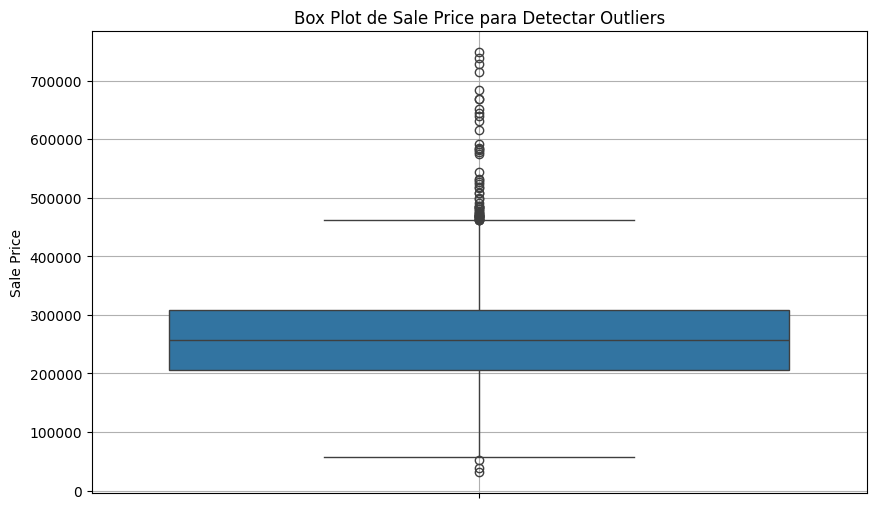

In [24]:
print('--- Detección de Outliers en `sale_price` (Método IQR) ---')

Q1 = df['sale_price'].quantile(0.25)
Q3 = df['sale_price'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df[(df['sale_price'] < lower_bound) | (df['sale_price'] > upper_bound)]

print(f'Q1 (25%): {Q1:,.2f}')
print(f'Q3 (75%): {Q3:,.2f}')
print(f'IQR: {IQR:,.2f}')
print(f'Límite Inferior para Outliers: {lower_bound:,.2f}')
print(f'Límite Superior para Outliers: {upper_bound:,.2f}')
print(f'Se detectaron {len(outliers)} valores atípicos en `sale_price` (aproximadamente {len(outliers)/len(df)*100:.2f}% del total).')

print('\n--- Visualización de Outliers en `sale_price` (Box Plot) ---')
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['sale_price'])
plt.title('Box Plot de Sale Price para Detectar Outliers')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()

---# Bloque C — Transformar

## Paso 8: Separar numéricas y categóricasSeparar las columnas según su tipo.

In [25]:
print('--- Separación de Columnas Numéricas y Categóricas ---')

# Seleccionar columnas numéricas
# Incluimos los tipos de Pandas Int64Dtype (nullable integer) en los numéricos
columnas_numericas = df.select_dtypes(include=['number', pd.Int64Dtype()]).columns.tolist()

# Seleccionar columnas categóricas
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()

print(f'Columnas Numéricas ({len(columnas_numericas)}):\n{columnas_numericas}')
print(f'\nColumnas Categóricas ({len(columnas_categoricas)}):\n{columnas_categoricas}')

--- Separación de Columnas Numéricas y Categóricas ---
Columnas Numéricas (7):
['lot_area', 'year_built', 'bedrooms', 'bathrooms', 'garage_cars', 'overall_qual', 'sale_price']

Columnas Categóricas (4):
['neighborhood', 'house_style', 'central_air', 'sale_condition']


## Paso 9: One-Hot EncodingConvertir las variables categóricas a formato numérico (0/1).

In [26]:
print('--- Aplicando One-Hot Encoding a variables categóricas ---')

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

print(f'Dimensiones del DataFrame después de One-Hot Encoding: {df_encoded.shape}')
print('\nPrimeras 5 filas del DataFrame con variables categóricas codificadas:')
display(df_encoded.head())

--- Aplicando One-Hot Encoding a variables categóricas ---
Dimensiones del DataFrame después de One-Hot Encoding: (20000, 23)

Primeras 5 filas del DataFrame con variables categóricas codificadas:


,lot_area,year_built,bedrooms,bathrooms,garage_cars,overall_qual,sale_price,neighborhood_Edwards,neighborhood_Gilbert,neighborhood_NWAmes,...,neighborhood_Somerst,house_style_1Story,house_style_2.5Unf,house_style_2Story,house_style_SFoyer,house_style_SLvl,central_air_Y,sale_condition_Family,sale_condition_Normal,sale_condition_Partial
0,6535.0,1934,2,2.5,2,5,204767.0,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,7633.0,2016,6,4.0,0,9,364732.0,False,False,True,...,False,False,False,True,False,False,True,False,True,False
2,11064.0,1988,3,3.5,2,5,346668.0,False,False,False,...,True,False,False,False,False,False,True,False,False,True
3,4518.0,1917,2,4.0,4,1,128357.0,False,False,True,...,False,False,False,False,False,False,True,False,True,False
4,6891.0,1907,3,3.5,3,2,147557.0,False,False,True,...,False,False,False,False,False,True,False,False,True,False


---# Bloque D — Validar y guardar

## Paso 10: Visualizar la variable objetivoGenerar un histograma de `sale_price` para ver su distribución.

--- Visualización y Estadísticas de `sale_price` ---
Estadísticas descriptivas de `sale_price`:


,sale_price
count,20000.000000
mean,257533.812350
std,72401.508761
min,30822.000000
25%,206251.750000
50%,256675.000000
75%,308218.500000
max,747909.000000


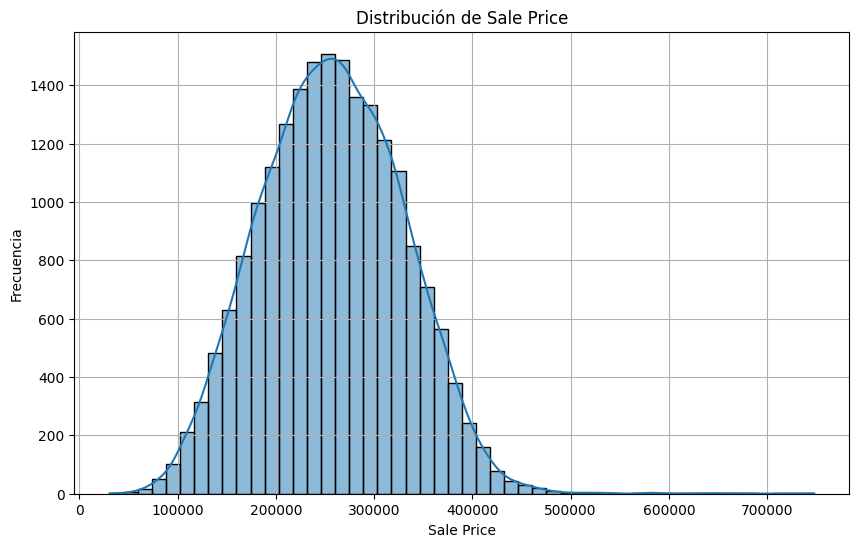

In [27]:
print('--- Visualización y Estadísticas de `sale_price` ---')

# Estadísticas descriptivas de sale_price
print('Estadísticas descriptivas de `sale_price`:')
display(df_encoded['sale_price'].describe().to_frame())

# Generar histograma
plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['sale_price'], kde=True, bins=50)
plt.title('Distribución de Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

## Paso 11: Guardar el dataset preparadoExportar el dataset listo como `house_prices_preparado.csv`.

In [28]:
print('--- Guardando el dataset preparado ---')

# Exportar el DataFrame df_encoded a un archivo CSV
df_encoded.to_csv('house_prices_preparado.csv', index=False)

print('El dataset preparado ha sido guardado exitosamente como "house_prices_preparado.csv"')

--- Guardando el dataset preparado ---
El dataset preparado ha sido guardado exitosamente como "house_prices_preparado.csv"


In [29]:
from google.colab import files

print('--- Descargar el dataset preparado ---')
files.download('house_prices_preparado.csv')

--- Descargar el dataset preparado ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>